# Binodal Stepper
In this notebook, I'll show how to use the stepper to trace binodal curves in phase diagrams for a ternary System.

All you need to start are the three interaction parameter between the components.

Took 1.39s to analyze phase diagram


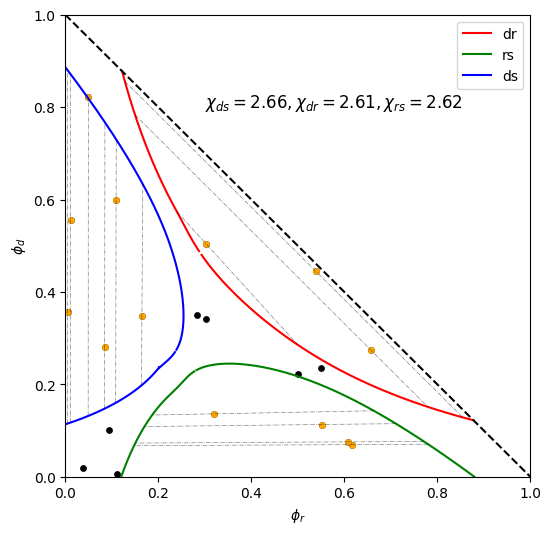

In [1]:
import time
import itertools
import matplotlib.pyplot as plt
import numpy as np

from pyphasediagram import PhaseDiagram

chi_ds, chi_dr, chi_rs = 2.66, 2.61, 2.62
diagram = PhaseDiagram(chi_dr, chi_rs, chi_ds)
n = time.perf_counter()
diagram.characterize()
print(f"Took {time.perf_counter() - n:.2f}s to analyze phase diagram")
diagram.plot_binodals()

## Binodal Data
The binodal data is stored inside the `PhaseDiagram.binodals` attribute as a list of arrays with shape (N_phases, N_components, N_points) = (2, 2, N_points).

Text(0, 0.5, '$\\phi_D$')

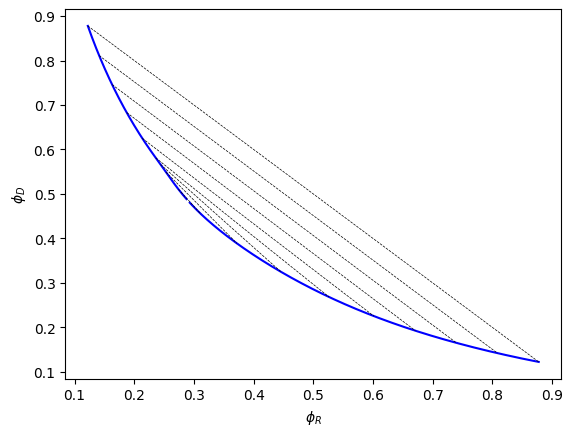

In [2]:
binodals = diagram.binodals[0]

# Plot first phase
plt.plot(binodals[0,0], binodals[0,1], color='blue')
# Plot second phase
plt.plot(binodals[1,0], binodals[1,1], color='blue')
# Plot tie lines
plt.plot(binodals[:,0,::100], binodals[:,1,::100], 'k--', linewidth=0.5)
# Volume fractions always in droplet-regulator space
plt.xlabel(r"$\phi_R$")
plt.ylabel(r"$\phi_D$")

## Infer Phase Compositions
We can also use the phasediagram to determine the compositions of coexisting phases given a mean composition. `PhaseDiagram.get_compositions` returns a list of compositions for each binodal branch.

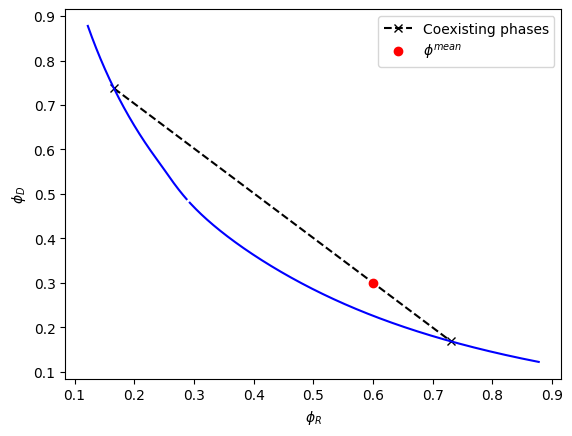

In [7]:
phi_mean = np.array([0.6, 0.3])
phi_comps = diagram.get_compositions(phi_mean)

for comp in phi_comps:
    
    if comp.shape == (2,2):# Coexisting phases
        plt.plot(comp[:,0], comp[:,1], 'k--x', label=r"Coexisting phases")
        plt.plot(phi_mean[0], phi_mean[1], 'ro', label=r"$\phi^{mean}$")
plt.plot(binodals[0,0], binodals[0,1], color='blue')
plt.plot(binodals[1,0], binodals[1,1], color='blue')
plt.xlabel(r"$\phi_R$")
plt.ylabel(r"$\phi_D$")
plt.legend()

Finding the coexisting phases is quite fast and could probably be faster once we facilitate vectorization

In [50]:
phi_m_arr = np.random.random((30000,2))
phi_m_arr = phi_m_arr[phi_m_arr.sum(axis=1)<=1][:10000]
n = time.perf_counter()
for phi_m in phi_m_arr:
    phi_comps = diagram.get_compositions(phi_m)
print(f"Took {time.perf_counter() - n:.2f}s to get compositions of {len(phi_m_arr)} mean volume fractions")


Took 0.83s to get compositions of 10000 mean volume fractions


## Three Phase Points
We can also get the three phase points from `PhaseDiagram.three_phase_points` which is a list containing a tuples with the three phase compositions for each three phase region.

/Users/msteen/Desktop/work/pyphasediagram/src/pyphasediagram/stepper.py:51: RuntimeWarning: invalid value encountered in log
  logx, logy, logz = np.log(x), np.log(y), np.log(z)


This binodal ds has already been found


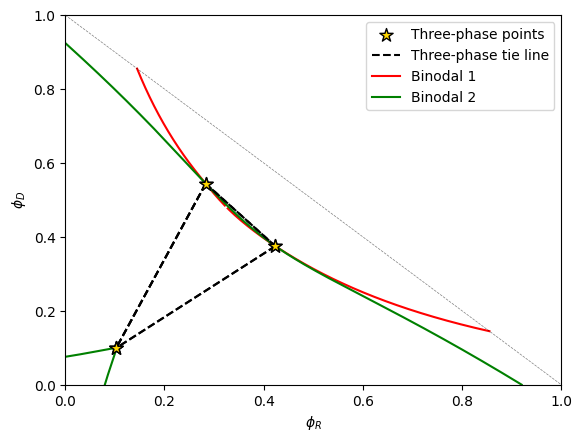

In [51]:

chi_ds, chi_dr, chi_rs = 2.95, 2.5, 2.91
diagram_tp = PhaseDiagram(chi_dr, chi_rs, chi_ds)
diagram_tp.characterize()

points_list = diagram_tp.three_phase_points

for points in points_list:
    # Plot three phase points on binodals
    for point in points:
        plt.scatter(point[0], point[1], marker='*', color='gold', edgecolor="black", s=100, zorder=5)
    # Plot tie lines
    for i, (p1, p2) in enumerate(itertools.combinations(points, 2)):
        plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'k--', linewidth=1.5, zorder=4)

# Plot again for legend
plt.scatter(point[0], point[1], marker='*', color='gold', edgecolor="black", s=100, label='Three-phase points')
plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'k--', linewidth=1.5, label="Three-phase tie line")

# Plot binodals
binodals_tp = diagram_tp.binodals
for i, binodal in enumerate(binodals_tp):
    for j, phase in enumerate(binodal):
        if j==0:
            plt.plot(phase[0], phase[1], color=diagram_tp.cl_cases[i], label=f"Binodal {i+1}")
        else:
            plt.plot(phase[0], phase[1], color=diagram_tp.cl_cases[i])
plt.plot([0,1], [1,0], 'k--', alpha=0.5, lw=0.5)
plt.xlim(0,1)
plt.ylim(0,1)
plt.xlabel(r"$\phi_R$")
plt.ylabel(r"$\phi_D$")
plt.legend()


